In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import os
import zipfile
zip_path="archive (2).zip"
extract_path="dataset"
os.makedirs(extract_path,exist_ok=True)
with zipfile.ZipFile(zip_path,"r") as zip_ref:
    zip_ref.extractall(extract_path)
print("dataset extracted!")

dataset extracted!


In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
df=pd.read_csv('dataset/american_bankruptcy.csv')
#first five rows
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [ ]:
#rows and columns
print(df.shape)
print("\nrows:",df.shape[0])
print("\ncolumns:",df.shape[1])
#datatypes and missing value
print("\ninformation:")
df.info()

(78682, 21)

rows: 78682

columns: 21

information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_name  78682 non-null  object 
 1   status_label  78682 non-null  object 
 2   year          78682 non-null  int64  
 3   X1            78682 non-null  float64
 4   X2            78682 non-null  float64
 5   X3            78682 non-null  float64
 6   X4            78682 non-null  float64
 7   X5            78682 non-null  float64
 8   X6            78682 non-null  float64
 9   X7            78682 non-null  float64
 10  X8            78682 non-null  float64
 11  X9            78682 non-null  float64
 12  X10           78682 non-null  float64
 13  X11           78682 non-null  float64
 14  X12           78682 non-null  float64
 15  X13           78682 non-null  float64
 16  X14           78682 non-null  float64
 17  X15           786

In [ ]:
#handling missing values
print("Missing Values:")
missing=df.isnull().sum()
# Fill numerical columns with median
if (missing==0).all():
  print("no missing values")
else:
  numeric_cols = df.select_dtypes(include='number').columns
  df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

Missing Values:
no missing values


In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"{duplicates} duplicate rows removed.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [ ]:
print(df["status_label"].value_counts())
print(df["status_label"].unique())

status_label
alive     73462
failed     5220
Name: count, dtype: int64
['alive' 'failed']


In [ ]:
# Create LabelEncoder object
label_encoder = LabelEncoder()
# Encode the target column
df["status_label"] = label_encoder.fit_transform(df["status_label"])
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [ ]:
print(df["status_label"].value_counts(dropna=False))

status_label
0    73462
1     5220
Name: count, dtype: int64


In [ ]:
#rename to actual names
df.rename(columns={
    "X1": "Current_Assets",
    "X2": "Cost_of_Goods_Sold",
    "X3": "Depreciation_Amortization",
    "X4": "EBITDA",
    "X5": "Inventory",
    "X6": "Net_Income",
    "X7": "Total_Receivables",
    "X8": "Market_Value",
    "X9": "Net_Sales",
    "X10": "Total_Assets",
    "X11": "Long_Term_Debt",
    "X12": "EBIT",
    "X13": "Gross_Profit",
    "X14": "Current_Liabilities",
    "X15": "Retained_Earnings",
    "X16": "Total_Revenue",
    "X17": "Total_Liabilities",
    "X18": "Operating_Expenses"
}, inplace=True)
df.head()

,company_name,status_label,year,Current_Assets,Cost_of_Goods_Sold,Depreciation_Amortization,EBITDA,Inventory,Net_Income,Total_Receivables,...,Net_Sales,Total_Assets,Long_Term_Debt,EBIT,Gross_Profit,Current_Liabilities,Retained_Earnings,Total_Revenue,Total_Liabilities,Operating_Expenses
0,C_1,0,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,0,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,0,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,0,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,0,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


In [ ]:
import numpy as np

# Count infinite values
inf_values = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

if inf_values > 0:
    print(f"{inf_values} infinite values found.")

    # Replace with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill using median
    df.fillna(df.median(numeric_only=True), inplace=True)

    print("Infinite values handled.")
else:
    print("No infinite values found.")

No infinite values found.


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

company_name: 8971 unique values
status_label: 2 unique values
year: 20 unique values
Current_Assets: 65895 unique values
Cost_of_Goods_Sold: 65690 unique values
Depreciation_Amortization: 36010 unique values
EBITDA: 59060 unique values
Inventory: 38898 unique values
Net_Income: 55550 unique values
Total_Receivables: 49577 unique values
Market_Value: 77580 unique values
Net_Sales: 68596 unique values
Total_Assets: 71521 unique values
Long_Term_Debt: 39741 unique values
EBIT: 56949 unique values
Gross_Profit: 64952 unique values
Current_Liabilities: 58685 unique values
Retained_Earnings: 72062 unique values
Total_Revenue: 68596 unique values
Total_Liabilities: 64640 unique values
Operating_Expenses: 70840 unique values


In [ ]:
# STEP 8 : Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
status_label,78682.0,0.066343,0.248882,0.0000,0.00000,0.00000,0.00000,1.00
year,78682.0,2007.506317,5.742768,1999.0000,2002.00000,2007.00000,2012.00000,2018.00
Current_Assets,78682.0,880.362485,3928.564794,-7.7600,18.92400,100.44950,431.52675,169662.00
Cost_of_Goods_Sold,78682.0,1594.529029,8930.484664,-366.6450,17.03825,103.66100,634.54800,374623.00
Depreciation_Amortization,78682.0,121.234256,652.376804,0.0000,1.19200,7.92950,47.97175,28430.00
EBITDA,78682.0,376.759424,2012.023142,-21913.0000,-0.81100,15.03450,139.65525,81730.00
Inventory,78682.0,201.605717,1060.766096,0.0000,0.00000,7.02300,74.74725,62567.00
Net_Income,78682.0,129.382453,1265.532022,-98696.0000,-7.41575,1.61600,40.14425,104821.00
Total_Receivables,78682.0,286.832743,1335.978571,-0.0060,3.28125,22.82000,131.58050,65812.00
Market_Value,78682.0,3414.354610,18414.103647,0.0001,34.98000,227.51185,1244.88995,1073390.54


In [ ]:
# STEP 9 : Class Distribution
print(df["status_label"].value_counts())
print("\nPercentage Distribution")
print(df["status_label"].value_counts(normalize=True)*100)

status_label
0    73462
1     5220
Name: count, dtype: int64

Percentage Distribution
status_label
0    93.3657
1     6.6343
Name: proportion, dtype: float64


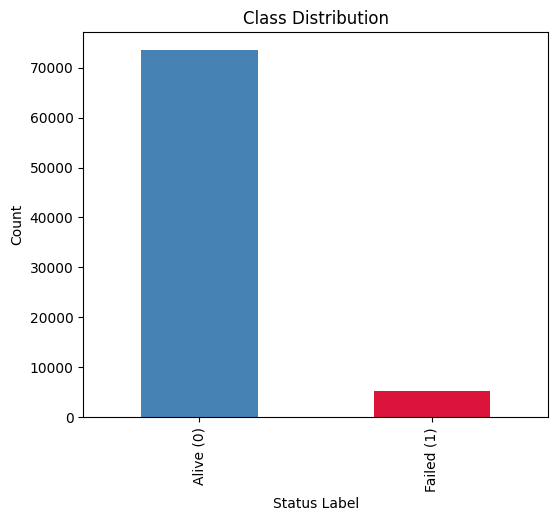

In [ ]:
#CLASS distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
df["status_label"].value_counts().plot(
    kind="bar",
    color=["steelblue","crimson"]
)
plt.title("Class Distribution")
plt.xlabel("Status Label")
plt.ylabel("Count")

plt.xticks([0,1],["Alive (0)","Failed (1)"])

plt.show()

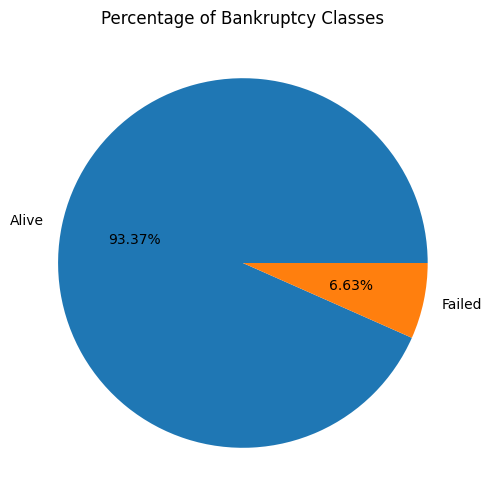

In [ ]:
plt.figure(figsize=(6,6))

df["status_label"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["Alive","Failed"]
)

plt.ylabel("")
plt.title("Percentage of Bankruptcy Classes")

plt.show()

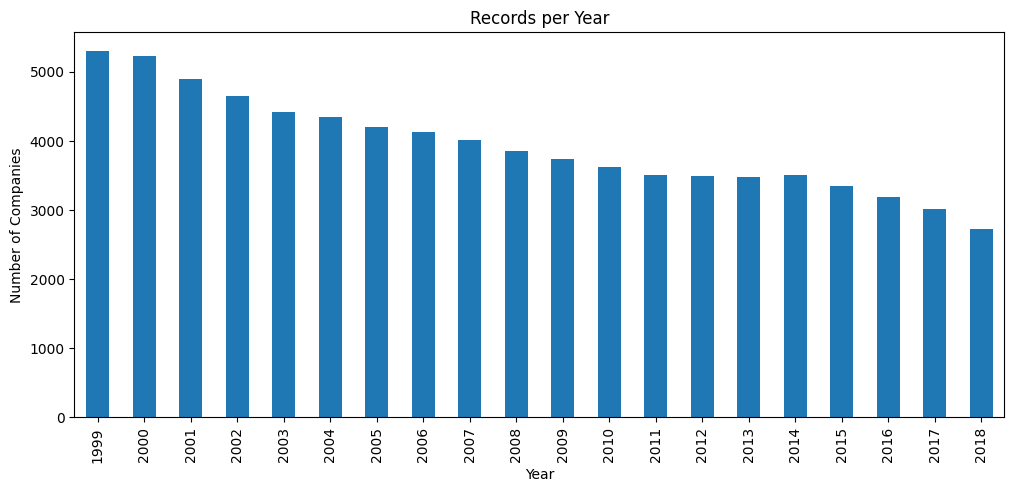

In [ ]:
#company records over years
plt.figure(figsize=(12,5))

df["year"].value_counts().sort_index().plot(kind="bar")

plt.title("Records per Year")

plt.xlabel("Year")

plt.ylabel("Number of Companies")

plt.show()

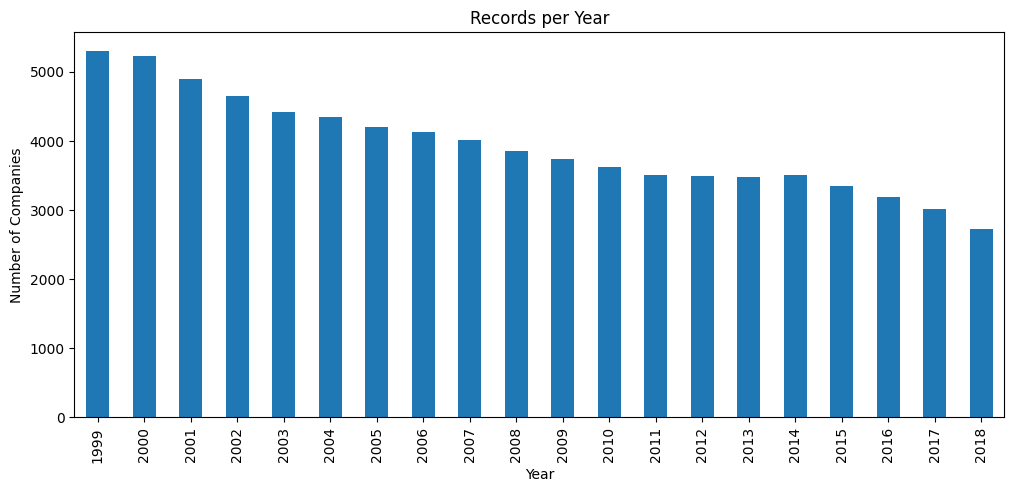

In [ ]:
#bankruptcy trend over years
plt.figure(figsize=(12,5))
df["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Records per Year")
plt.xlabel("Year")
plt.ylabel("Number of Companies")
plt.show()

In [ ]:
# Separate Features and Target
# Input Features
X = df.drop(columns=["company_name", "status_label"])

# Target Variable
y = df["status_label"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (78682, 19)
Target Shape: (78682,)


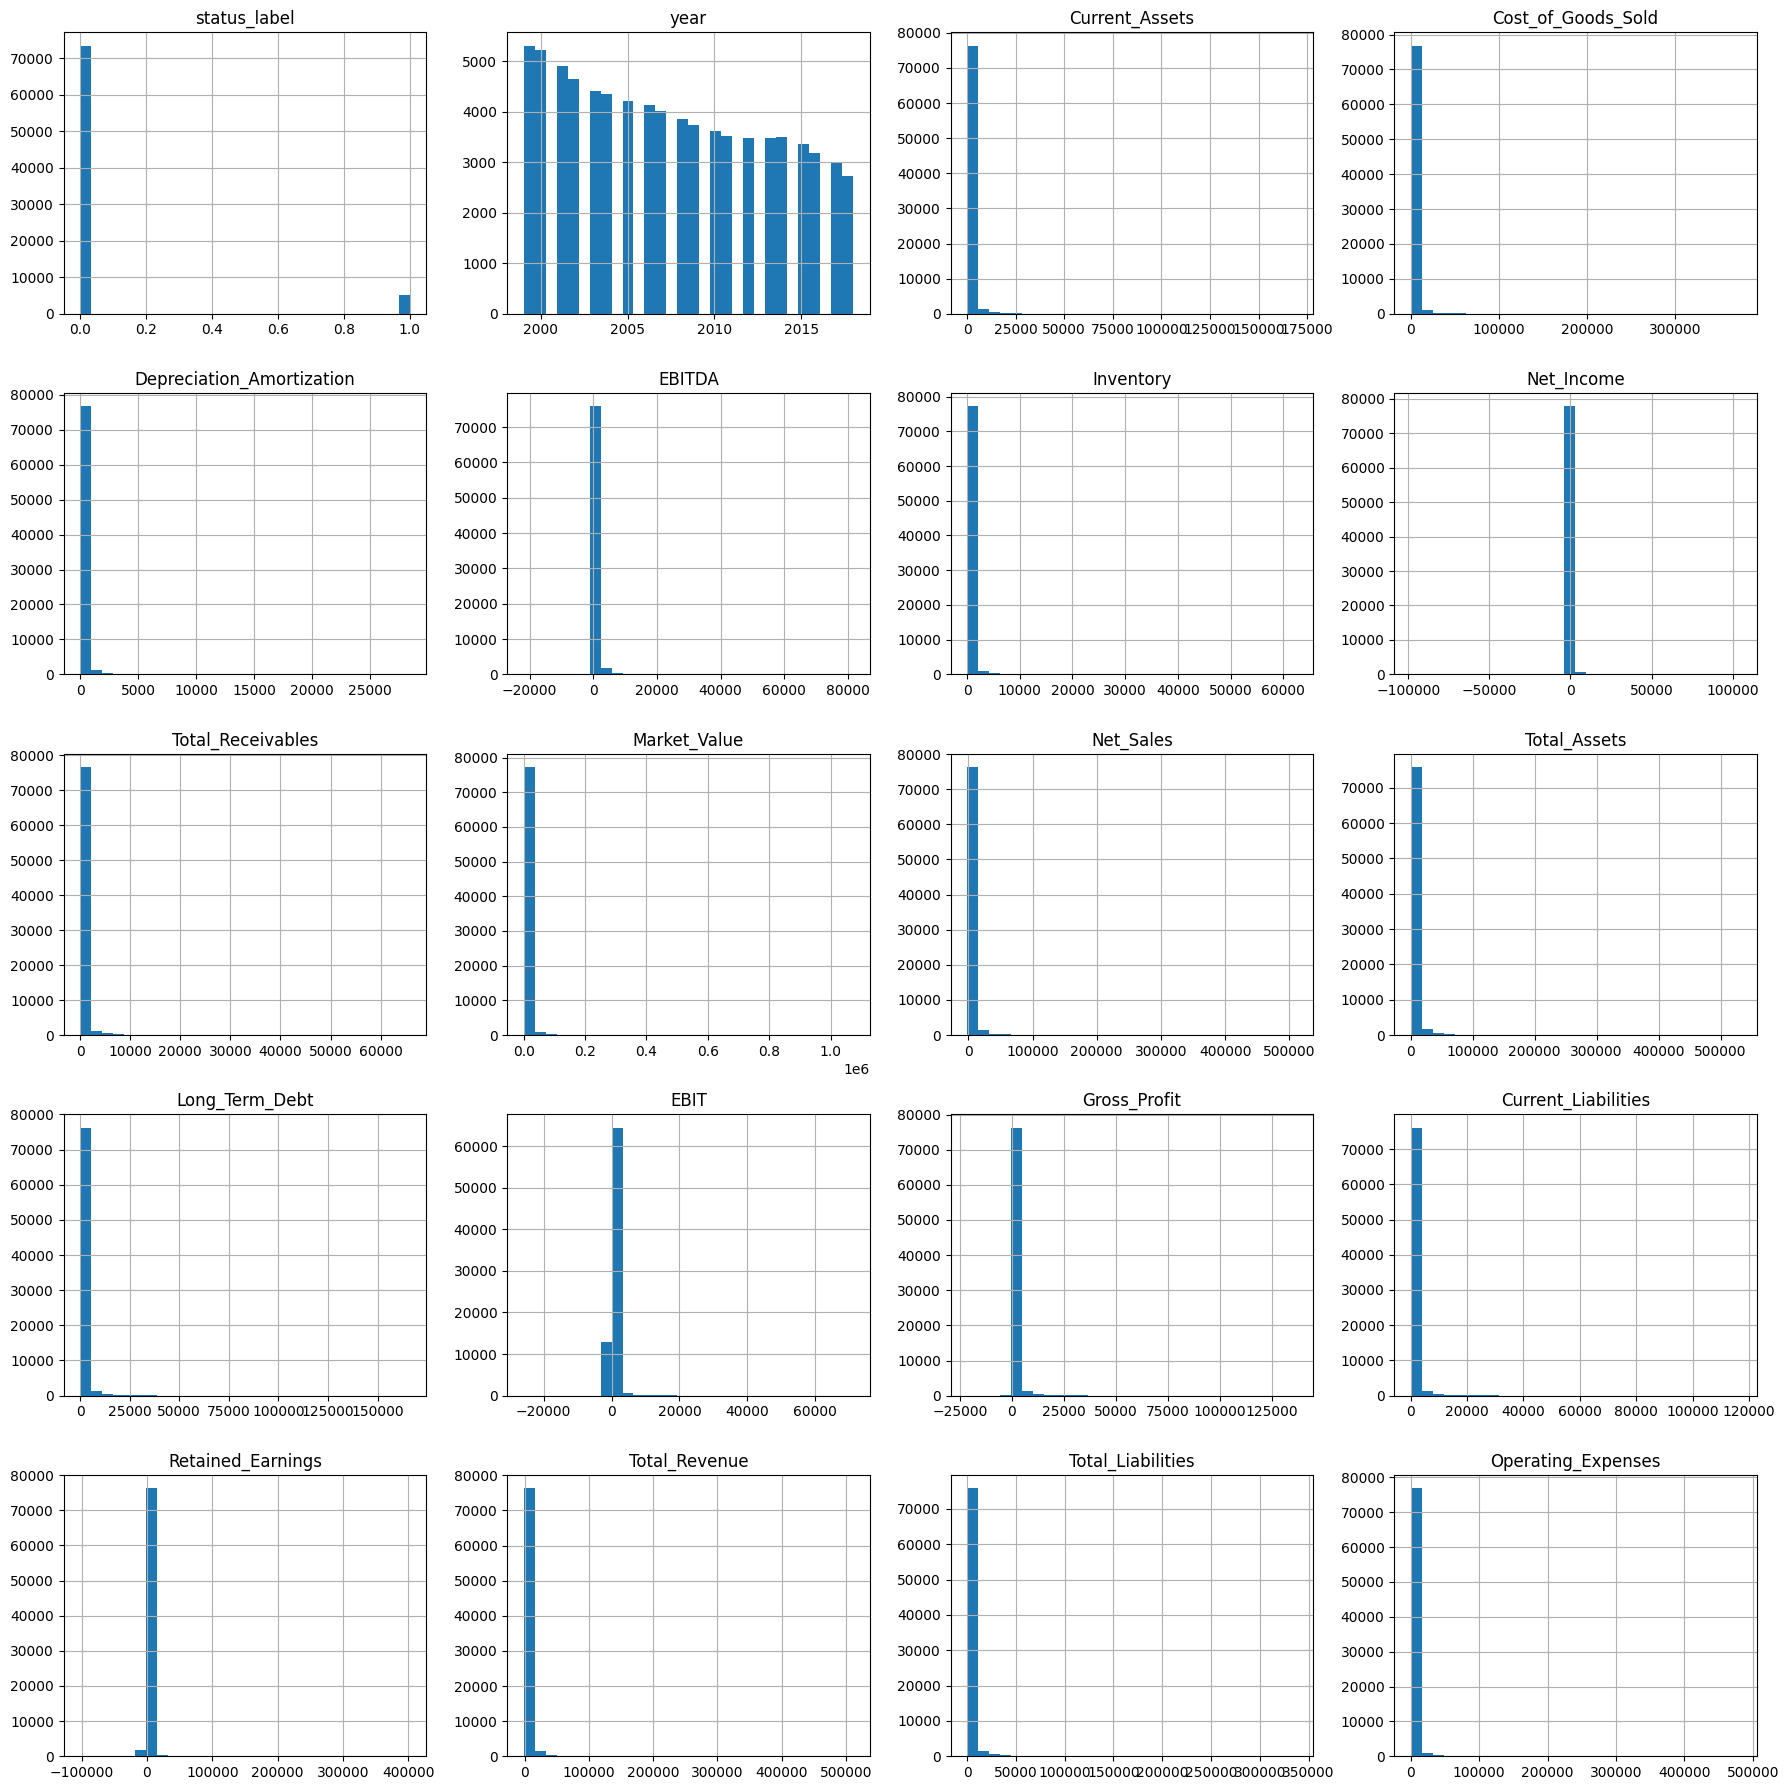

In [ ]:
import matplotlib.pyplot as plt
#DISTRIBUTION OF FINANCIAL FEATURES
numeric_columns = df.select_dtypes(include=['number']).columns
df[numeric_columns].hist(
    figsize=(18,18),
    bins=30
)
plt.tight_layout()
plt.show()

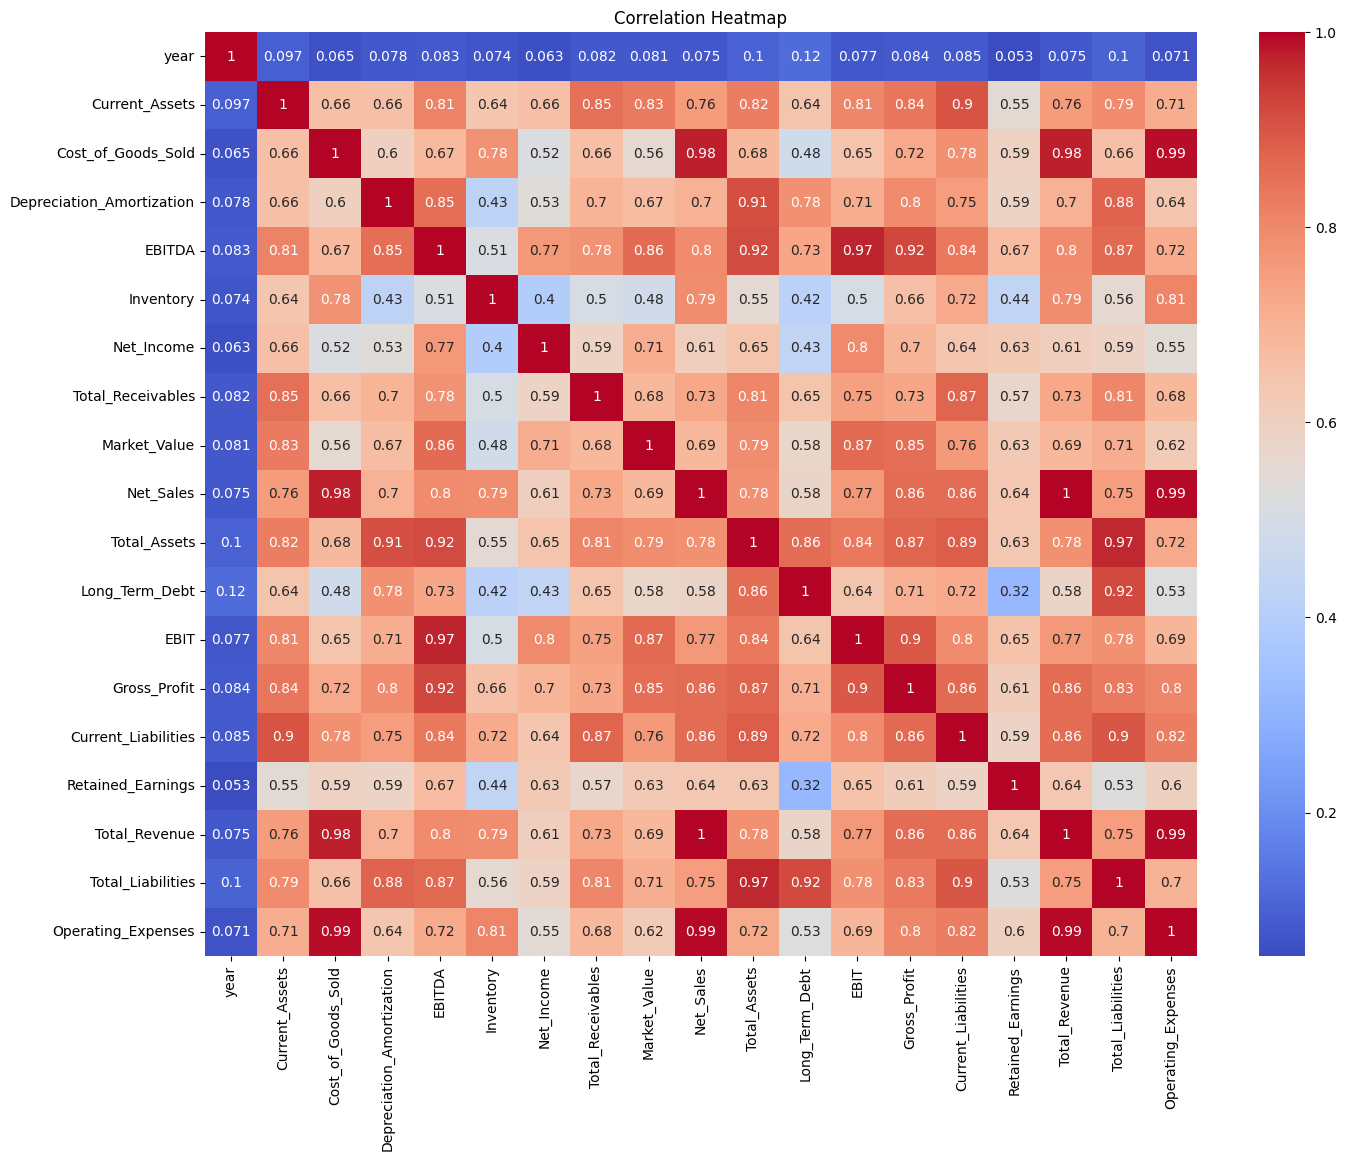

In [ ]:
import seaborn as sns
plt.figure(figsize=(16,12))
sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
financial_features = df.select_dtypes(include=["number"]).columns.tolist()

# Remove the target column
if "status_label" in financial_features:
    financial_features.remove("status_label")

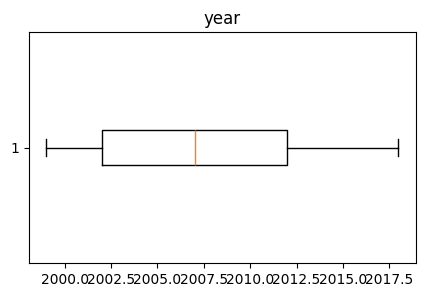

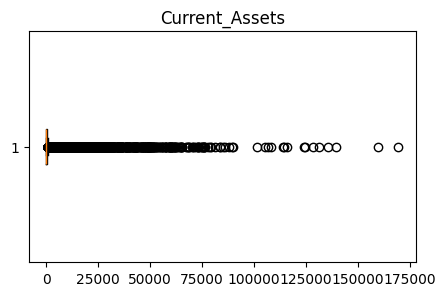

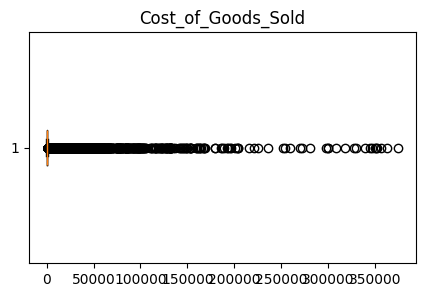

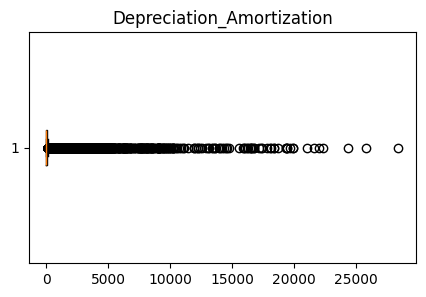

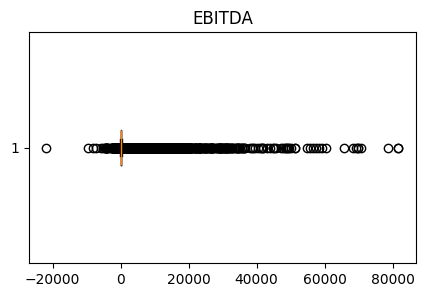

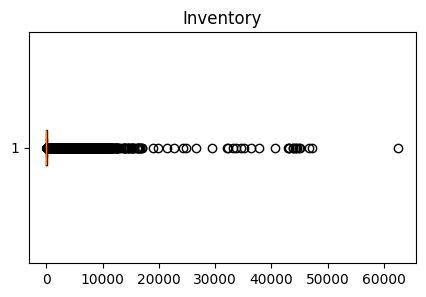

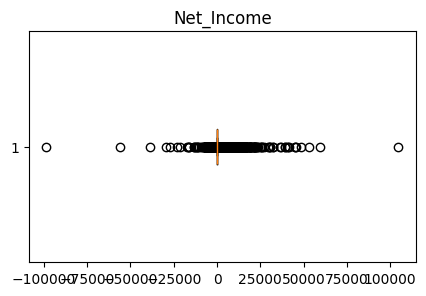

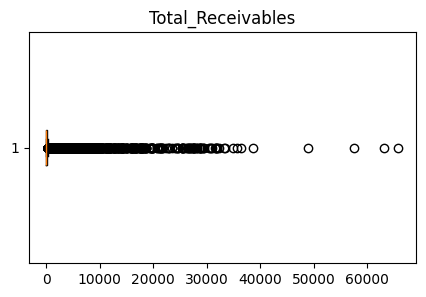

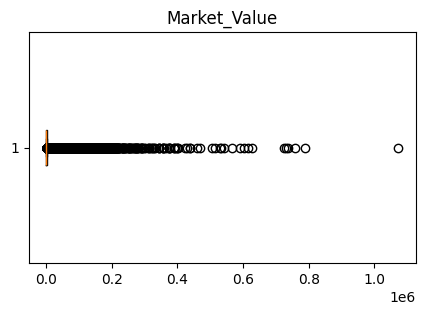

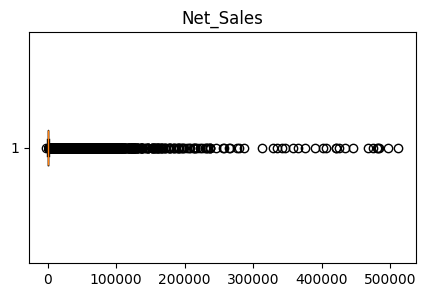

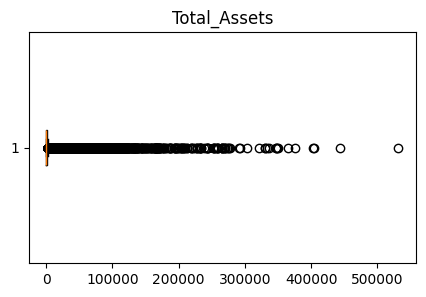

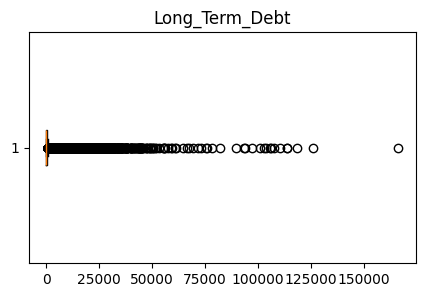

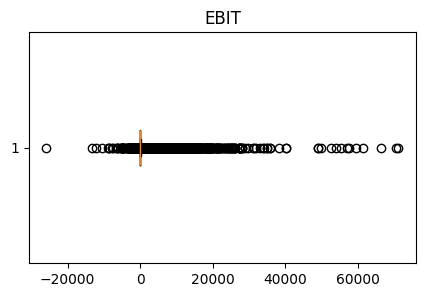

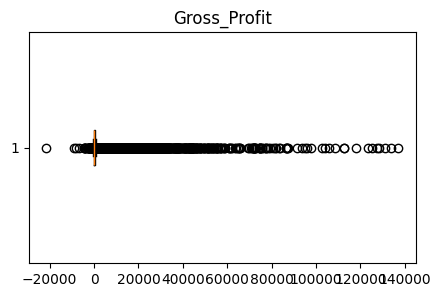

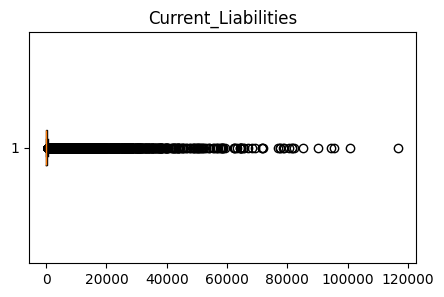

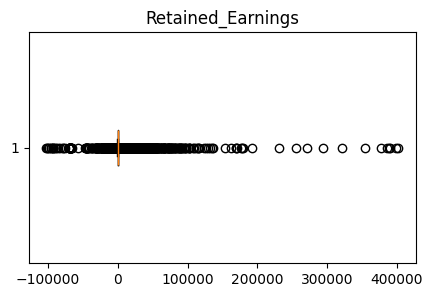

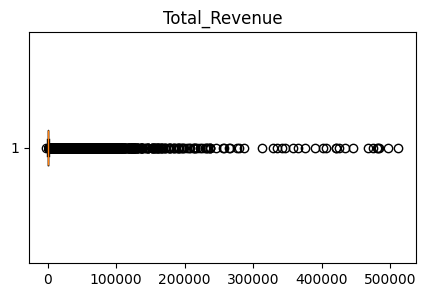

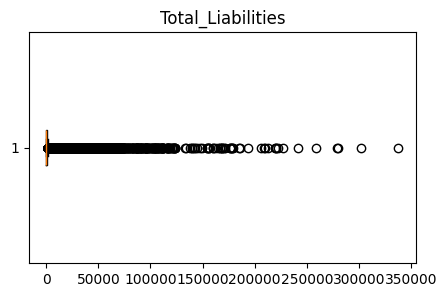

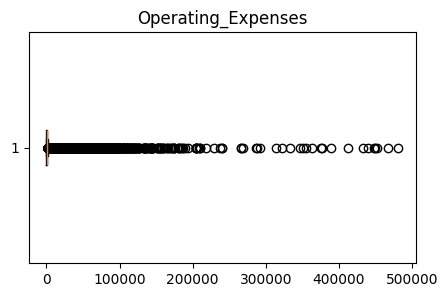

In [ ]:
for col in df.select_dtypes(include=['number']).columns:
    if col != "status_label":
        plt.figure(figsize=(5,3))
        plt.boxplot(df[col], vert=False)
        plt.title(col)
        plt.show()

In [ ]:
skewness = df[financial_features].skew()
print(skewness.sort_values(ascending=False))

Retained_Earnings            29.607949
Inventory                    22.568626
Operating_Expenses           20.384520
Cost_of_Goods_Sold           20.052194
Net_Sales                    18.987110
Total_Revenue                18.987110
Market_Value                 18.194283
EBIT                         17.968030
Depreciation_Amortization    17.860473
EBITDA                       16.403531
Total_Receivables            15.844958
Gross_Profit                 15.295829
Long_Term_Debt               14.848021
Current_Assets               14.843279
Current_Liabilities          14.225186
Total_Liabilities            13.767802
Total_Assets                 13.562208
Net_Income                   11.866809
year                          0.193910
dtype: float64


In [ ]:
df.to_csv("cleaned_bankruptcy_dataset.csv", index=False)
print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [ ]:
X = df.drop(columns=["company_name", "status_label"])
y = df["status_label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (62945, 19)
Testing Shape  : (15737, 19)


In [ ]:
#20% train 80%test data split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)
print(X_train.shape)
print(X_test.shape)

(62945, 19)
(15737, 19)


In [ ]:
#checking imbalance
print(y_train.value_counts())
print("\nPercentage")
print(y_train.value_counts(normalize=True) * 100)

status_label
0    58769
1     4176
Name: count, dtype: int64

Percentage
status_label
0    93.365637
1     6.634363
Name: proportion, dtype: float64


In [ ]:
#implementing smote on training dataset
#create new samples instead of duplicate to manage imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
print(y_train_smote.value_counts())

status_label
0    58769
1    58769
Name: count, dtype: int64


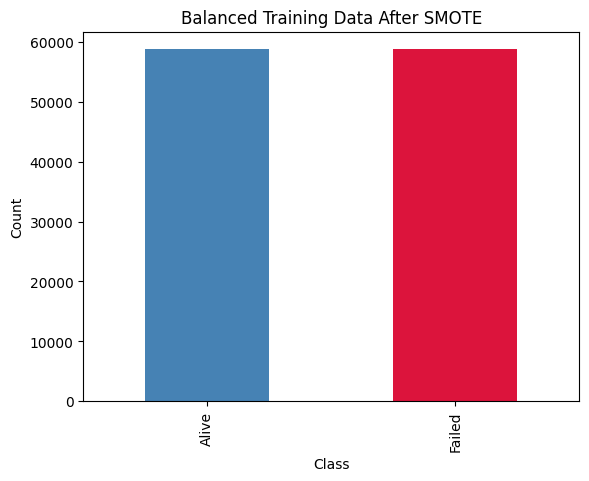

In [ ]:
y_train_smote.value_counts().plot(
    kind="bar",
    color=["steelblue", "crimson"]
)
plt.title("Balanced Training Data After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1],["Alive","Failed"])
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7423905445764758
Precision: 0.15965626413387607
Recall   : 0.6762452107279694
F1 Score : 0.2583241858763264
ROC AUC  : 0.7972438070308977


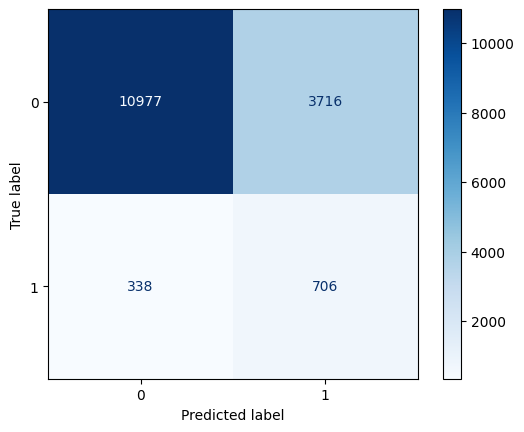

In [ ]:
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    cmap="Blues"
)
plt.show()

In [ ]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

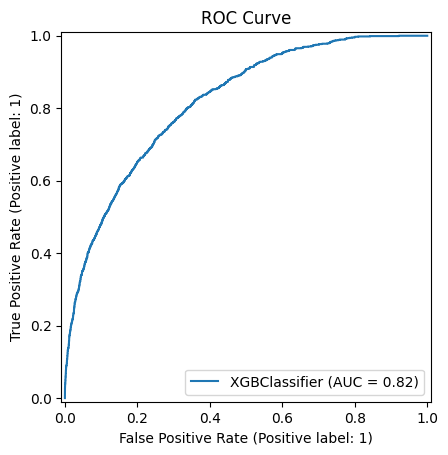

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [ ]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.923619,0.435458,0.510536,0.470018,0.885361
3,XGBoost,0.823855,0.216163,0.630268,0.321918,0.834332
1,Decision Tree,0.853085,0.229753,0.516284,0.317994,0.696650
0,Logistic Regression,0.578319,0.098967,0.660920,0.172156,0.655976


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

In [ ]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

Best Cross Validation ROC-AUC:
0.9926150902175509


In [ ]:
best_xgb = random_search.best_estimator_

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9205058143229332
Precision: 0.429061000685401
Recall   : 0.5996168582375478
F1 Score : 0.5001997602876548
ROC-AUC  : 0.8893020707595791

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.94      0.96     14693
           1       0.43      0.60      0.50      1044

    accuracy                           0.92     15737
   macro avg       0.70      0.77      0.73     15737
weighted avg       0.93      0.92      0.93     15737



In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,year,0.125131
6,Net_Income,0.083031
11,Long_Term_Debt,0.072910
5,Inventory,0.059473
8,Market_Value,0.055626
3,Depreciation_Amortization,0.053684
7,Total_Receivables,0.049744
18,Operating_Expenses,0.049165
17,Total_Liabilities,0.048731
15,Retained_Earnings,0.048333


/tmp/ipykernel_1047/2403372481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


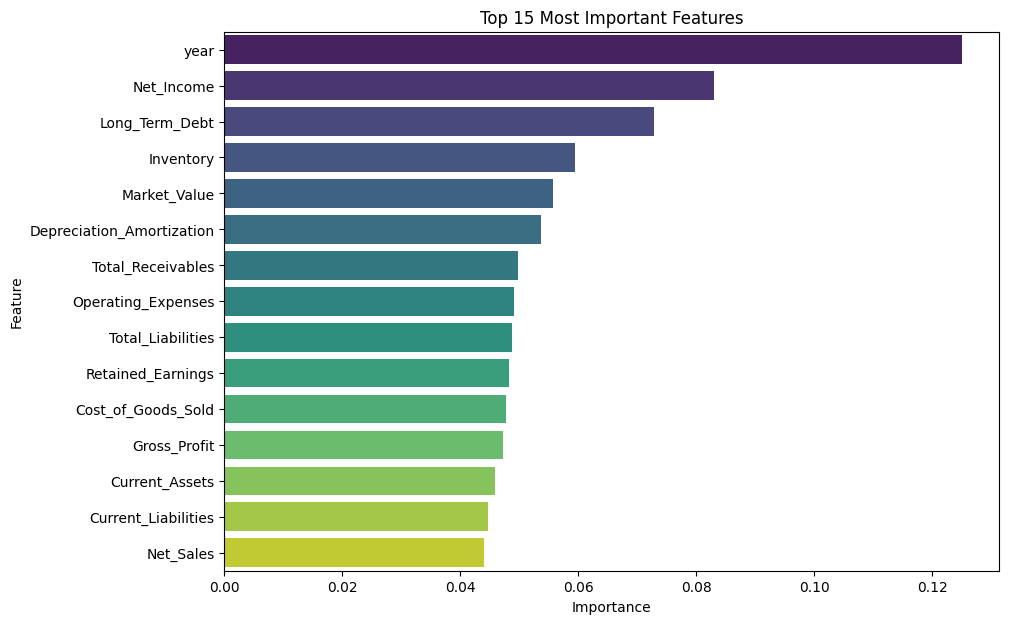

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
!pip install shap

In [ ]:
import shap
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

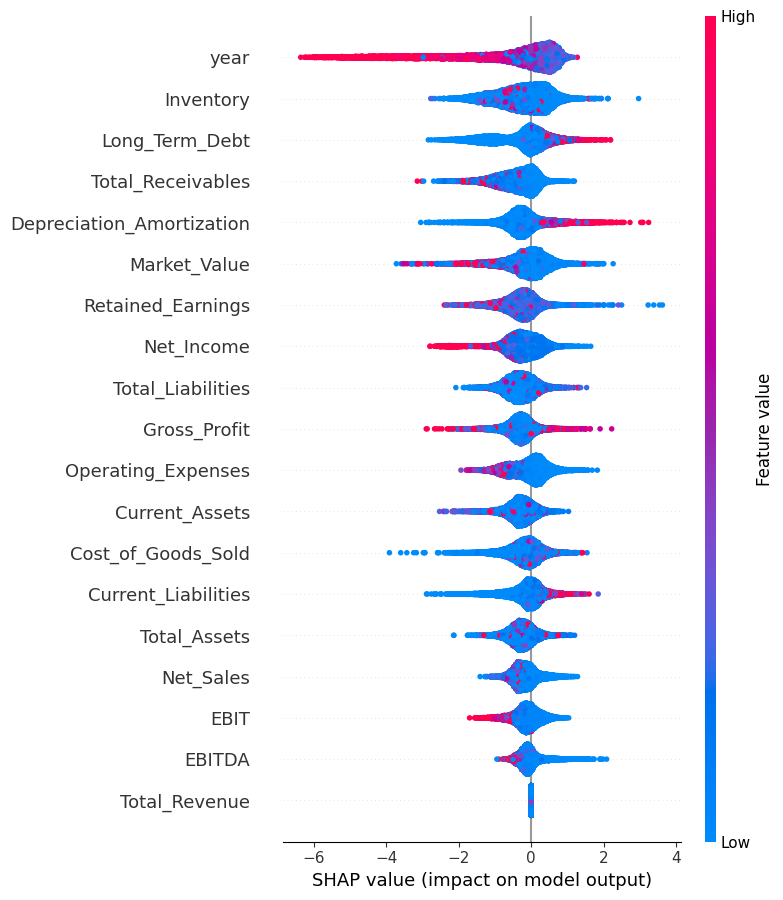

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

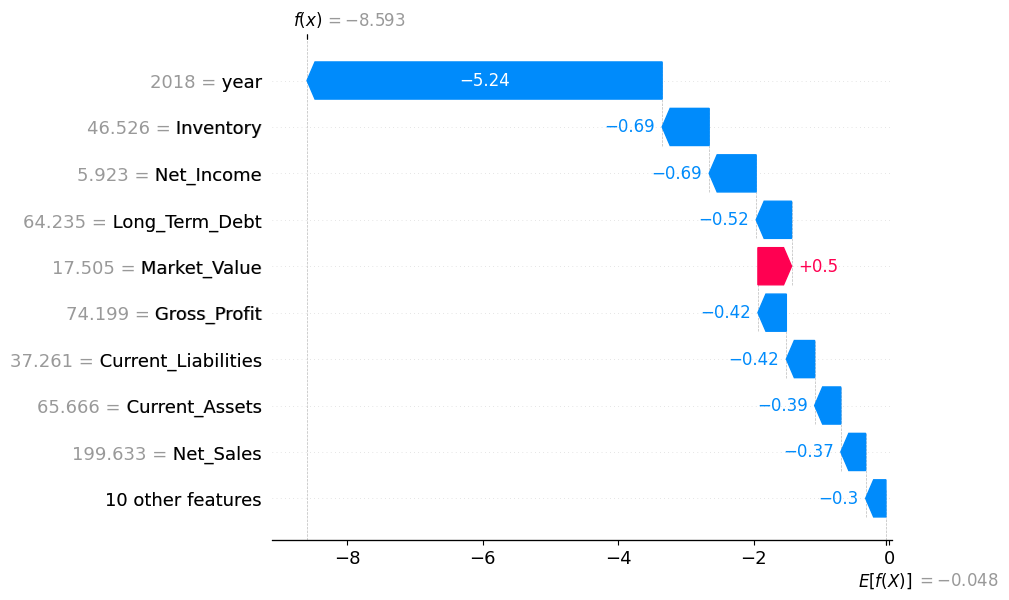

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

In [ ]:
import joblib
joblib.dump(best_xgb, "bankruptcy_model.pkl")
print("Model saved successfully!")

Model saved successfully!


Prediction Explanation
⬇ year reduced bankruptcy risk.
⬇ Inventory reduced bankruptcy risk.
⬇ Net_Income reduced bankruptcy risk.
⬇ Long_Term_Debt reduced bankruptcy risk.
⬆ Market_Value increased bankruptcy risk.

Top 5 Important Features:


,Feature,Feature Value,SHAP Value,Impact
0,year,2018.000,-5.241557,5.241557
5,Inventory,46.526,-0.694137,0.694137
6,Net_Income,5.923,-0.693644,0.693644
11,Long_Term_Debt,64.235,-0.522367,0.522367
8,Market_Value,17.505,0.496474,0.496474


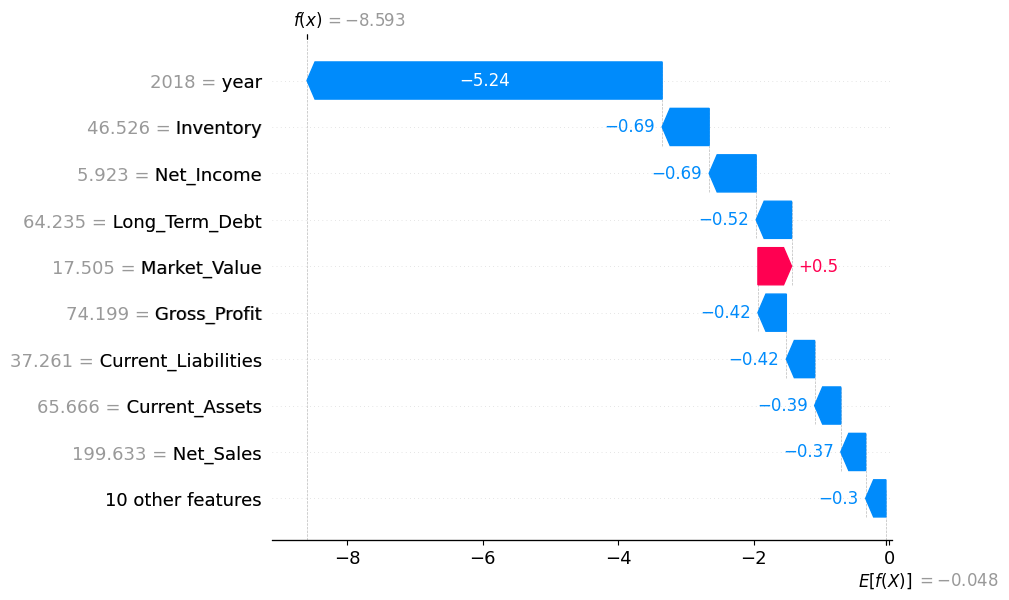

In [ ]:
# SHAP Explainability
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(best_xgb)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Choose a company to explain (change index if needed)
company_index = 0

# Create explanation dataframe
explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": X_test.iloc[company_index].values,
    "SHAP Value": shap_values[company_index]
})

# Sort by absolute SHAP value
explanation["Impact"] = explanation["SHAP Value"].abs()
explanation = explanation.sort_values(by="Impact", ascending=False)

print("="*60)
print("Prediction Explanation")
print("="*60)

for _, row in explanation.head(5).iterrows():
    if row["SHAP Value"] > 0:
        print(f"⬆ {row['Feature']} increased bankruptcy risk.")
    else:
        print(f"⬇ {row['Feature']} reduced bankruptcy risk.")

print("\nTop 5 Important Features:")
display(explanation.head(5))

# Waterfall Plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[company_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[company_index],
        feature_names=X_test.columns
    )
)

In [ ]:
import joblib
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("="*60)
print("Saving Project Files...")
print("="*60)

# Save ML Model
joblib.dump(best_xgb, "bankruptcy_model.pkl")
print("Saved: bankruptcy_model.pkl")

# Save Label Encoder (if exists)
try:
    joblib.dump(le, "label_encoder.pkl")
    print("Saved: label_encoder.pkl")
except:
    print("Label Encoder not found (Skipped)")

# Save Scaler (if exists)
try:
    joblib.dump(scaler, "scaler.pkl")
    print("Saved: scaler.pkl")
except:
    print("Scaler not used (Skipped)")

# Save Feature Importance CSV
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.to_csv("feature_importance.csv", index=False)
print("Saved: feature_importance.csv")

# Save Model Comparison
try:
    results_df.to_csv("model_results.csv", index=False)
    print("Saved: model_results.csv")
except:
    print("Model comparison dataframe not found.")

# Feature Importance Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False,
    palette="viridis"
)

plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.close()

print("Saved: feature_importance.png")

# Confusion Matrix
y_pred = best_xgb.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.close()

print("Saved: confusion_matrix.png")


# ROC Curve
RocCurveDisplay.from_estimator(
    best_xgb,
    X_test,
    y_test
)

plt.title("ROC Curve")
plt.savefig("roc_curve.png", dpi=300)
plt.close()

print("Saved: roc_curve.png")

# SHAP Summary Plot
try:
    import shap

    explainer = shap.TreeExplainer(best_xgb)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(
        shap_values,
        X_test,
        show=False
    )

    plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
    plt.close()

    print("Saved: shap_summary.png")

except Exception as e:
    print("SHAP plot not saved:", e)

print("\n" + "="*60)
print("EXPORT COMPLETE")
print("="*60)

print("""
Files Generated:
bankruptcy_model.pkl
feature_importance.csv
feature_importance.png
confusion_matrix.png
roc_curve.png
shap_summary.png
model_results.csv (if available)
scaler.pkl (if used)
label_encoder.pkl (if used)
""")

Saving Project Files...
Saved: bankruptcy_model.pkl
Label Encoder not found (Skipped)
Scaler not used (Skipped)
Saved: feature_importance.csv
Saved: model_results.csv
Saved: feature_importance.png
Saved: confusion_matrix.png
Saved: roc_curve.png
Saved: shap_summary.png

EXPORT COMPLETE

Files Generated:
bankruptcy_model.pkl
feature_importance.csv
feature_importance.png
confusion_matrix.png
roc_curve.png
shap_summary.png
model_results.csv (if available)
scaler.pkl (if used)
label_encoder.pkl (if used)



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install dependencies
!pip install flask pyngrok

In [ ]:
sample = df.head(1)

sample.to_csv("sample_company.csv", index=False)

In [ ]:
print("Uploaded columns:")
print(df.columns.tolist())

print("\nColumns used for prediction:")
print(X.columns.tolist())

Uploaded columns:
['company_name', 'status_label', 'year', 'Current_Assets', 'Cost_of_Goods_Sold', 'Depreciation_Amortization', 'EBITDA', 'Inventory', 'Net_Income', 'Total_Receivables', 'Market_Value', 'Net_Sales', 'Total_Assets', 'Long_Term_Debt', 'EBIT', 'Gross_Profit', 'Current_Liabilities', 'Retained_Earnings', 'Total_Revenue', 'Total_Liabilities', 'Operating_Expenses']

Columns used for prediction:
['year', 'Current_Assets', 'Cost_of_Goods_Sold', 'Depreciation_Amortization', 'EBITDA', 'Inventory', 'Net_Income', 'Total_Receivables', 'Market_Value', 'Net_Sales', 'Total_Assets', 'Long_Term_Debt', 'EBIT', 'Gross_Profit', 'Current_Liabilities', 'Retained_Earnings', 'Total_Revenue', 'Total_Liabilities', 'Operating_Expenses']


In [ ]:
import joblib
import shap
model = joblib.load("bankruptcy_model.pkl")
# Create SHAP explainer once
explainer = shap.TreeExplainer(model)

In [ ]:
from flask import Flask
from pyngrok import ngrok

In [ ]:
from google.colab import userdata
token = userdata.get("NGROK_TOKEN")
ngrok.set_auth_token(token)

In [ ]:
from flask import Flask, request, render_template_string
import pandas as pd
import numpy as np
import joblib
import shap
import json

app = Flask(__name__)

MODEL = joblib.load("bankruptcy_model.pkl")
EXPLAINER = shap.TreeExplainer(MODEL)

FEATURE_ORDER = [
    "year", "Current_Assets", "Cost_of_Goods_Sold", "Depreciation_Amortization",
    "EBITDA", "Inventory", "Net_Income", "Total_Receivables", "Market_Value",
    "Net_Sales", "Total_Assets", "Long_Term_Debt", "EBIT", "Gross_Profit",
    "Current_Liabilities", "Retained_Earnings", "Total_Revenue",
    "Total_Liabilities", "Operating_Expenses"
]

MODEL_METRICS = {
    "Accuracy": 0.9205, "Precision": 0.4291,
    "Recall": 0.5996, "F1 Score": 0.5002, "ROC-AUC": 0.8893
}

GLOSSARY = {
    "year": "The fiscal year this financial data was reported for.",
    "Current_Assets": "Assets expected to be converted to cash within one year.",
    "Cost_of_Goods_Sold": "Direct costs of producing the goods or services sold.",
    "Depreciation_Amortization": "Non-cash expense reflecting asset wear and intangible amortization.",
    "EBITDA": "Earnings Before Interest, Taxes, Depreciation and Amortization.",
    "Inventory": "Value of unsold goods currently on hand.",
    "Net_Income": "Bottom-line profit after all expenses and taxes.",
    "Total_Receivables": "Money owed to the company by its customers.",
    "Market_Value": "Market capitalization -- the total value of the company.",
    "Net_Sales": "Revenue after returns, allowances and discounts.",
    "Total_Assets": "Everything the company owns.",
    "Long_Term_Debt": "Debt obligations due after one year.",
    "EBIT": "Earnings Before Interest and Taxes.",
    "Gross_Profit": "Net sales minus cost of goods sold.",
    "Current_Liabilities": "Obligations due within one year.",
    "Retained_Earnings": "Cumulative profits kept in the business rather than paid out as dividends.",
    "Total_Revenue": "Total income generated from operations.",
    "Total_Liabilities": "Everything the company owes.",
    "Operating_Expenses": "Day-to-day costs of running the business, excluding COGS.",
}

FEATURE_META = {
    "year": {"label": "Fiscal Year", "default": 2015, "category": "Company Info"},
    "Current_Assets": {"label": "Current Assets ($M)", "default": 100.4, "category": "Liquidity"},
    "Current_Liabilities": {"label": "Current Liabilities ($M)", "default": 43.3, "category": "Liquidity"},
    "Inventory": {"label": "Inventory ($M)", "default": 7.0, "category": "Liquidity"},
    "Total_Receivables": {"label": "Total Receivables ($M)", "default": 22.8, "category": "Liquidity"},
    "Net_Sales": {"label": "Net Sales ($M)", "default": 186.6, "category": "Profitability"},
    "Total_Revenue": {"label": "Total Revenue ($M)", "default": 186.6, "category": "Profitability"},
    "Cost_of_Goods_Sold": {"label": "Cost of Goods Sold ($M)", "default": 103.7, "category": "Profitability"},
    "Gross_Profit": {"label": "Gross Profit ($M)", "default": 63.6, "category": "Profitability"},
    "Operating_Expenses": {"label": "Operating Expenses ($M)", "default": 168.9, "category": "Profitability"},
    "EBITDA": {"label": "EBITDA ($M)", "default": 15.0, "category": "Profitability"},
    "EBIT": {"label": "EBIT ($M)", "default": 6.5, "category": "Profitability"},
    "Depreciation_Amortization": {"label": "Depreciation & Amortization ($M)", "default": 7.9, "category": "Profitability"},
    "Net_Income": {"label": "Net Income ($M)", "default": 1.6, "category": "Profitability"},
    "Total_Assets": {"label": "Total Assets ($M)", "default": 213.2, "category": "Capital Structure"},
    "Total_Liabilities": {"label": "Total Liabilities ($M)", "default": 82.0, "category": "Capital Structure"},
    "Long_Term_Debt": {"label": "Long-Term Debt ($M)", "default": 7.6, "category": "Capital Structure"},
    "Retained_Earnings": {"label": "Retained Earnings ($M)", "default": -1.1, "category": "Capital Structure"},
    "Market_Value": {"label": "Market Value ($M)", "default": 227.5, "category": "Capital Structure"},
}
CATEGORY_ORDER = ["Company Info", "Liquidity", "Profitability", "Capital Structure"]
CATEGORY_ICONS = {"Company Info": "🏢", "Liquidity": "💧", "Profitability": "📈", "Capital Structure": "🏛️"}


def gloss(feat):
    """Returns an HTML span with a dotted underline and hover tooltip for a feature name."""
    name = feat.replace("_", " ")
    definition = GLOSSARY.get(feat, "").replace('"', "'")
    return f'<span class="glossary-term" data-tooltip="{definition}">{name}</span>'


def risk_level(p):
    if p < 0.20:
        return "Low Risk", "#16A34A"
    elif p < 0.45:
        return "Moderate Risk", "#EAB308"
    elif p < 0.70:
        return "High Risk", "#F97316"
    else:
        return "Critical Risk", "#DC2626"


def compute_row(name, x_row, shap_row, prob, row_id):
    """Builds the full card-data dict for one company given its feature row + shap values."""
    label, color = risk_level(prob)

    contrib = pd.DataFrame({"Feature": FEATURE_ORDER, "SHAP": shap_row})
    contrib["Abs"] = contrib["SHAP"].abs()
    top5 = contrib.sort_values("Abs", ascending=False).head(5)
    max_abs = top5["Abs"].max() or 1.0

    factors = [{
        "name_html": gloss(r["Feature"]),
        "width": round((r["Abs"] / max_abs) * 100, 1),
        "color": "#DC2626" if r["SHAP"] > 0 else "#16A34A",
        "direction": "↑ increases risk" if r["SHAP"] > 0 else "↓ decreases risk"
    } for _, r in top5.iterrows()]

    full_data = [{"name_html": gloss(feat), "value": round(float(x_row[feat]), 3)} for feat in FEATURE_ORDER]

    all_sorted = contrib.sort_values("Abs", ascending=False)
    all_shap = [{
        "name_html": gloss(r["Feature"]),
        "shap": round(float(r["SHAP"]), 4),
        "direction": "increases risk" if r["SHAP"] > 0 else "decreases risk"
    } for _, r in all_sorted.iterrows()]

    return {
        "id": row_id, "name": str(name), "prob": round(float(prob) * 100, 1),
        "label": label, "color": color, "factors": factors,
        "full_data": full_data, "all_shap": all_shap
    }


def build_trend_svg(points):
    """points: list of (year, prob_pct) sorted by year. Returns an inline SVG sparkline string."""
    if len(points) < 2:
        return ""
    W, H, PAD = 300, 90, 12
    years = [p[0] for p in points]
    vals = [p[1] for p in points]
    vmin, vmax = min(vals), max(vals)
    vrange = (vmax - vmin) or 1
    n = len(points)
    xs = [PAD + i * (W - 2 * PAD) / (n - 1) for i in range(n)]
    ys = [H - PAD - ((v - vmin) / vrange) * (H - 2 * PAD) for v in vals]
    poly = " ".join(f"{x:.1f},{y:.1f}" for x, y in zip(xs, ys))
    circles = "".join(f'<circle cx="{x:.1f}" cy="{y:.1f}" r="3.5" fill="#1E3A5F"/>' for x, y in zip(xs, ys))
    labels = "".join(
        f'<text x="{x:.1f}" y="{H-1}" font-size="9" fill="var(--muted)" text-anchor="middle">{yr}</text>'
        for x, yr in zip(xs, years)
    )
    return f'''<svg viewBox="0 0 {W} {H}" style="width:100%; max-width:340px; height:auto;">
        <polyline points="{poly}" fill="none" stroke="#1E3A5F" stroke-width="2.5"/>
        {circles}{labels}
    </svg>'''


# ----------------------------------------------------------------------------
# Shared styling
# ----------------------------------------------------------------------------
BASE_STYLE = """
<style>
* { box-sizing: border-box; }
:root {
    --bg:#F1F5F9; --surface:#FFFFFF; --surface-soft:#F8FAFC;
    --text:#1E293B; --muted:#64748B; --border:#E2E8F0; --nav-bg:#0F172A;
}
[data-theme="dark"] {
    --bg:#0B1220; --surface:#111827; --surface-soft:#1A2333;
    --text:#E5E7EB; --muted:#94A3B8; --border:#243043; --nav-bg:#000000;
}
body {
    margin: 0; font-family: 'Segoe UI', Arial, sans-serif;
    background: var(--bg); color: var(--text);
    transition: background .2s ease, color .2s ease;
}
.navbar {
    background: var(--nav-bg); padding: 14px 40px;
    display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 10px;
}
.navbar .brand { color: white; font-weight: 700; font-size: 1.1rem; }
.navbar .nav-links a {
    color: #CBD5E1; text-decoration: none; margin-left: 24px; font-size: .92rem; font-weight: 600;
}
.navbar .nav-links a:hover, .navbar .nav-links a.active { color: white; }
.theme-toggle {
    background: rgba(255,255,255,.1); border: 1px solid rgba(255,255,255,.2);
    color: white; border-radius: 999px; padding: 6px 14px; cursor: pointer; font-size: .85rem;
    margin-left: 20px; transition: background .2s;
}
.theme-toggle:hover { background: rgba(255,255,255,.2); }
.topbar {
    background: linear-gradient(135deg, #0F172A 0%, #1E3A5F 100%);
    color: white; padding: 28px 40px;
}
.topbar h1 { margin: 0; font-size: 1.8rem; }
.topbar p { margin: 6px 0 0 0; opacity: .85; font-size: .95rem; }
.wrap { max-width: 1000px; margin: 0 auto; padding: 32px 20px 60px 20px; }
.card {
    background: var(--surface); border: 1px solid var(--border); border-radius: 16px;
    padding: 32px; box-shadow: 0 2px 10px rgba(0,0,0,.06); margin-bottom: 24px;
    transition: transform .18s ease, box-shadow .18s ease;
}
.card:hover { transform: translateY(-3px); box-shadow: 0 10px 26px rgba(0,0,0,.10); }
.dropzone {
    border: 2px dashed #94A3B8; border-radius: 12px; padding: 40px 20px;
    text-align: center; background: var(--surface-soft); transition: border-color .2s;
}
.dropzone:hover { border-color: #1E3A5F; }
.filename { margin-top: 12px; font-size: .9rem; color: var(--muted); }
button, .btn {
    padding: 14px; background: #1E3A5F; color: white; border: none; border-radius: 10px;
    font-size: 1rem; font-weight: 600; cursor: pointer; margin-top: 18px;
    text-decoration: none; display: inline-block; text-align: center;
    transition: transform .12s ease, background .15s ease;
}
button.full-width, .btn.full-width { width: 100%; }
button:hover, .btn:hover { background: #16324E; transform: scale(1.015); }
.btn-outline {
    background: transparent; color: #1E3A5F; border: 1px solid #1E3A5F;
}
[data-theme="dark"] .btn-outline { color: #93C5FD; border-color: #93C5FD; }
.btn-outline:hover { background: rgba(30,58,95,.08); transform: scale(1.015); }
.btn-sm { padding: 8px 14px; font-size: .8rem; margin-top: 0; }
table { width: 100%; border-collapse: collapse; margin-top: 12px; font-size: .88rem; }
th, td { padding: 10px 12px; border-bottom: 1px solid var(--border); text-align: left; }
th { background: var(--surface-soft); font-weight: 600; cursor: pointer; user-select: none; }
th.sortable:hover { background: var(--border); }
tbody tr { transition: background .12s ease; }
tbody tr:hover { background: var(--surface-soft); }
.badge {
    display: inline-block; padding: 5px 16px; border-radius: 999px;
    font-weight: 700; font-size: .95rem; color: white;
}
.badge-sm { padding: 3px 12px; font-size: .8rem; }
.bar-row { display: flex; align-items: center; margin-bottom: 10px; gap: 10px; }
.bar-label { width: 190px; font-size: .85rem; color: var(--text); flex-shrink: 0; }
.bar-track { flex: 1; background: var(--border); border-radius: 6px; height: 16px; overflow: hidden; }
.bar-fill { height: 100%; border-radius: 6px; width: var(--w); animation: growBar .9s ease; }
@keyframes growBar { from { width: 0; } to { width: var(--w); } }
.result-header { display: flex; justify-content: space-between; align-items: center; flex-wrap: wrap; gap: 16px; }
.prob-num { font-size: 2.4rem; font-weight: 800; }
.stat-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(150px, 1fr)); gap: 16px; }
.stat-box { background: var(--surface-soft); border-radius: 12px; padding: 18px; text-align: center; }
.stat-box .num { font-size: 1.8rem; font-weight: 800; }
.stat-box .lbl { font-size: .8rem; color: var(--muted); margin-top: 4px; }
.donut-wrap { display: flex; align-items: center; gap: 32px; flex-wrap: wrap; }
.donut { width: 160px; height: 160px; border-radius: 50%; position: relative; flex-shrink: 0; transition: transform .2s; }
.donut:hover { transform: scale(1.04); }
.donut::after { content: ""; position: absolute; top: 22px; left: 22px; width: 116px; height: 116px; border-radius: 50%; background: var(--surface); }
.gauge-label {
    position: absolute; inset: 0; z-index: 2; display: flex; align-items: center; justify-content: center;
    font-weight: 800; font-size: 1.4rem;
}
.legend { display: flex; flex-direction: column; gap: 10px; }
.legend-item { display: flex; align-items: center; gap: 10px; font-size: .9rem; }
.legend-dot { width: 12px; height: 12px; border-radius: 3px; }
.filter-bar { display: flex; gap: 10px; flex-wrap: wrap; margin-bottom: 14px; align-items: center; }
.filter-btn {
    padding: 8px 16px; border-radius: 999px; border: 1px solid var(--border);
    background: var(--surface); font-size: .85rem; font-weight: 600; cursor: pointer; color: var(--text);
    transition: all .15s;
}
.filter-btn:hover { border-color: #1E3A5F; }
.filter-btn.active { background: #1E3A5F; color: white; border-color: #1E3A5F; }
.search-input {
    padding: 9px 14px; border-radius: 999px; border: 1px solid var(--border);
    background: var(--surface); color: var(--text); font-size: .85rem; min-width: 200px;
    margin-left: auto;
}
details { margin-top: 18px; }
summary {
    cursor: pointer; font-weight: 600; color: #1E3A5F; padding: 10px 0; border-top: 1px solid var(--border);
}
[data-theme="dark"] summary { color: #93C5FD; }
.detail-table td, .detail-table th { font-size: .82rem; padding: 7px 10px; }
.metric-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(140px, 1fr)); gap: 16px; margin-top: 12px; }
.metric-box { background: var(--surface-soft); border-radius: 12px; padding: 20px; text-align: center; transition: transform .15s; }
.metric-box:hover { transform: translateY(-2px); }
.metric-box .num { font-size: 1.6rem; font-weight: 800; color: #1E3A5F; }
[data-theme="dark"] .metric-box .num { color: #93C5FD; }
.metric-box .lbl { font-size: .8rem; color: var(--muted); margin-top: 6px; }
.glossary-term { border-bottom: 1px dotted var(--muted); cursor: help; position: relative; }
.glossary-term:hover::after {
    content: attr(data-tooltip); position: absolute; bottom: 130%; left: 0;
    background: #0F172A; color: white; padding: 8px 12px; border-radius: 8px;
    font-size: .75rem; width: 220px; z-index: 50; box-shadow: 0 4px 12px rgba(0,0,0,.25);
    white-space: normal; line-height: 1.4;
}
.tabs { display: flex; gap: 8px; margin-bottom: 22px; border-bottom: 1px solid var(--border); }
.tab-btn {
    padding: 12px 20px; background: none; border: none; font-size: .95rem; font-weight: 600;
    color: var(--muted); cursor: pointer; margin: 0; border-bottom: 2px solid transparent;
}
.tab-btn.active { color: #1E3A5F; border-bottom-color: #1E3A5F; }
[data-theme="dark"] .tab-btn.active { color: #93C5FD; border-bottom-color: #93C5FD; }
.tab-panel { display: none; }
.tab-panel.active { display: block; }
.trend-card { text-align: center; }
.loading-overlay {
    display: none; position: fixed; inset: 0; background: rgba(15,23,42,.75);
    z-index: 999; align-items: center; justify-content: center; flex-direction: column; color: white;
}
.loading-overlay.show { display: flex; }
.spinner {
    width: 46px; height: 46px; border: 4px solid rgba(255,255,255,.25);
    border-top-color: white; border-radius: 50%; animation: spin .8s linear infinite;
}
@keyframes spin { to { transform: rotate(360deg); } }
.loading-overlay p { margin-top: 16px; font-size: .95rem; }
@media print {
    .navbar, .no-print, .filter-bar, .search-input { display: none !important; }
    body.print-mode .card:not(.print-target) { display: none !important; }
    .card { box-shadow: none; border: 1px solid #ccc; }
}
</style>
"""

THEME_INIT_SCRIPT = """
<script>
(function() {
    var t = localStorage.getItem('finguard-theme') || 'light';
    document.documentElement.setAttribute('data-theme', t);
})();
</script>
"""

LOADING_OVERLAY_HTML = """
<div class="loading-overlay no-print" id="loadingOverlay">
    <div class="spinner"></div>
    <p>Analyzing company financials...</p>
</div>
<script>
function showLoading() {
    document.getElementById('loadingOverlay').classList.add('show');
}
</script>
"""

COMMON_SCRIPT = """
<script>
function toggleTheme() {
    var html = document.documentElement;
    var current = html.getAttribute('data-theme') || 'light';
    var next = current === 'light' ? 'dark' : 'light';
    html.setAttribute('data-theme', next);
    localStorage.setItem('finguard-theme', next);
}
function printReport(cardId) {
    document.body.classList.add('print-mode');
    document.querySelectorAll('.card').forEach(c => c.classList.remove('print-target'));
    document.getElementById(cardId).classList.add('print-target');
    window.print();
}
window.onafterprint = function() { document.body.classList.remove('print-mode'); };
</script>
"""


def html_doc(title, body):
    return f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>{title}</title>
{THEME_INIT_SCRIPT}
{BASE_STYLE}
</head>
<body>
{body}
{COMMON_SCRIPT}
</body>
</html>"""


def nav(active):
    def link(href, label, key):
        cls = "active" if key == active else ""
        return f'<a href="{href}" class="{cls}">{label}</a>'
    return f"""
    <div class="navbar no-print">
        <div class="brand">🛡️ FinGuard AI</div>
        <div style="display:flex; align-items:center;">
            <div class="nav-links">
                {link("/", "Home", "home")}
                {link("/about", "About &amp; Model Info", "about")}
            </div>
            <button class="theme-toggle" onclick="toggleTheme()">🌓 Theme</button>
        </div>
    </div>
    """

# ----------------------------------------------------------------------------
# Home page: tabs for Batch Upload vs Manual Entry
# ----------------------------------------------------------------------------
def render_manual_form_fields():
    html = ""
    for category in CATEGORY_ORDER:
        feats = [f for f in FEATURE_ORDER if FEATURE_META[f]["category"] == category]
        html += f'<h4 style="margin:18px 0 8px 0; color:#1E3A5F;">{CATEGORY_ICONS[category]} {category}</h4>'
        html += '<div style="display:grid; grid-template-columns:repeat(auto-fit, minmax(200px,1fr)); gap:14px;">'
        for feat in feats:
            meta = FEATURE_META[feat]
            html += f"""
            <div>
              <label style="font-size:.82rem; font-weight:600; display:block; margin-bottom:5px;">{gloss(feat)}</label>
              <input type="number" step="any" name="{feat}" value="{meta['default']}"
                     style="width:100%; padding:9px 10px; border-radius:8px; border:1px solid var(--border); background:var(--surface); color:var(--text);">
            </div>
            """
        html += "</div>"
    return html


def home_body():
    manual_fields = render_manual_form_fields()
    return nav("home") + f"""
<div class="topbar">
    <h1>🛡️ FinGuard AI</h1>
    <p>Explainable AI for Early Financial Distress &amp; Bankruptcy Risk Assessment</p>
</div>
<div class="wrap">
  <div class="card">
    <div class="tabs">
      <button class="tab-btn active" onclick="switchTab('batch', this)">📂 Batch Upload (CSV)</button>
      <button class="tab-btn" onclick="switchTab('manual', this)">✍️ Manual Entry</button>
    </div>

    <div class="tab-panel active" id="tab-batch">
      <p style="color:var(--muted);">Upload a CSV with one row per company. Required columns: year, Current_Assets, Cost_of_Goods_Sold, Depreciation_Amortization, EBITDA, Inventory, Net_Income, Total_Receivables, Market_Value, Net_Sales, Total_Assets, Long_Term_Debt, EBIT, Gross_Profit, Current_Liabilities, Retained_Earnings, Total_Revenue, Total_Liabilities, Operating_Expenses.</p>
      <form action="/predict" method="POST" enctype="multipart/form-data" onsubmit="showLoading()">
        <div class="dropzone">
          <div style="font-size:2rem;">📄</div>
          <div>Choose a CSV file to analyze</div>
          <input type="file" name="file" accept=".csv" required
                 onchange="document.getElementById('fname').innerText = this.files[0]?.name || ''">
          <div class="filename" id="fname"></div>
        </div>
        <button type="submit" class="full-width">🔍 Run Risk Assessment</button>
      </form>
    </div>

    <div class="tab-panel" id="tab-manual">
      <p style="color:var(--muted);">Enter one company's financials directly. Hover any underlined term for a quick definition.</p>
      <form action="/predict-manual" method="POST" onsubmit="showLoading()">
        <div>
          <label style="font-size:.82rem; font-weight:600;">Company Name (optional)</label>
          <input type="text" name="company_name" placeholder="e.g. Acme Corp"
                 style="width:100%; padding:9px 10px; border-radius:8px; border:1px solid var(--border); background:var(--surface); color:var(--text); margin-top:5px;">
        </div>
        {manual_fields}
        <button type="submit" class="full-width">🔍 Assess This Company</button>
      </form>
    </div>
  </div>
</div>
{LOADING_OVERLAY_HTML}
<script>
function switchTab(name, btn) {{
    document.querySelectorAll('.tab-btn').forEach(b => b.classList.remove('active'));
    document.querySelectorAll('.tab-panel').forEach(p => p.classList.remove('active'));
    btn.classList.add('active');
    document.getElementById('tab-' + name).classList.add('active');
}}
</script>
"""


ERROR_BODY = """
<div class="topbar"><h1>🛡️ FinGuard AI</h1></div>
<div class="wrap">
  <div class="card">
    <h2 style="color:#DC2626;">Something went wrong</h2>
    <p>{error}</p>
    <a class="btn" href="/">← Back to home</a>
  </div>
</div>
"""

# ----------------------------------------------------------------------------
# Routes
# ----------------------------------------------------------------------------
@app.route("/")
def home():
    return html_doc("FinGuard AI", home_body())


@app.route("/about")
def about():
    importances = pd.DataFrame({
        "Feature": MODEL.feature_names_in_,
        "Importance": MODEL.feature_importances_
    }).sort_values("Importance", ascending=False).head(12)
    max_imp = importances["Importance"].max()

    bars = ""
    for _, row in importances.iterrows():
        width = round((row["Importance"] / max_imp) * 100, 1)
        pct = round(row["Importance"] * 100, 1)
        bars += f"""
        <div class="bar-row">
          <div class="bar-label">{gloss(row['Feature'])}</div>
          <div class="bar-track"><div class="bar-fill" style="--w:{width}%; background:#1E3A5F;"></div></div>
          <div style="width:60px; font-size:.8rem; color:var(--muted); text-align:right;">{pct}%</div>
        </div>"""

    metric_boxes = "".join(
        f'<div class="metric-box"><div class="num">{val*100:.1f}%</div><div class="lbl">{name}</div></div>'
        for name, val in MODEL_METRICS.items()
    )

    body = nav("about") + f"""
    <div class="topbar">
        <h1>About FinGuard</h1>
        <p>Model performance, methodology, and global feature importance</p>
    </div>
    <div class="wrap">
      <div class="card">
        <h2 style="margin-top:0;">How It Works</h2>
        <p style="color:var(--muted); line-height:1.6;">
          FinGuard uses a tuned <b>XGBoost</b> classifier trained on 18 financial statement
          variables plus fiscal year, across 1999-2018 company-year records. Class imbalance
          was addressed with <b>SMOTE</b> oversampling, and hyperparameters were tuned with
          <b>RandomizedSearchCV</b> optimizing ROC-AUC. Each prediction is explained using
          <b>SHAP</b> values, showing exactly which figures pushed a company's risk score up or down.
        </p>
      </div>
      <div class="card">
        <h2 style="margin-top:0;">Model Performance</h2>
        <div class="metric-grid">{metric_boxes}</div>
      </div>
      <div class="card">
        <h2 style="margin-top:0;">Global Feature Importance</h2>
        <p style="color:var(--muted); font-size:.9rem;">Which financial factors matter most to the model overall, across all predictions.</p>
        {bars}
      </div>
      <div class="card">
        <p style="color:var(--muted); font-size:.85rem; margin:0;">
          <b>Disclaimer:</b> FinGuard is a decision-support tool, not financial advice.
        </p>
      </div>
    </div>
    """
    return html_doc("About | FinGuard AI", body)


@app.route("/predict", methods=["POST"])
def predict():
    try:
        file = request.files["file"]
        df = pd.read_csv(file)

        missing = [c for c in FEATURE_ORDER if c not in df.columns]
        if missing:
            return html_doc("Error | FinGuard", nav("home") + ERROR_BODY.format(
                error=f"Missing required columns: {', '.join(missing)}"))

        X = df[FEATURE_ORDER].apply(pd.to_numeric, errors="coerce")
        if X.isnull().any().any():
            return html_doc("Error | FinGuard", nav("home") + ERROR_BODY.format(
                error="Some values could not be read as numbers. Please check your CSV."))

        probs = MODEL.predict_proba(X)[:, 1]
        shap_values = EXPLAINER.shap_values(X)

        rows = []
        counts = {"Low Risk": 0, "Moderate Risk": 0, "High Risk": 0, "Critical Risk": 0}
        names_for_trend = {}

        for i in range(len(df)):
            name = df["company_name"].iloc[i] if "company_name" in df.columns else f"Company {i+1}"
            row = compute_row(name, X.iloc[i], shap_values[i], probs[i], row_id=f"card-{i}")
            counts[row["label"]] += 1
            rows.append(row)
            names_for_trend.setdefault(str(name), []).append((int(X.iloc[i]["year"]), row["prob"]))

        total = len(rows)
        summary = {"total": total, "low": counts["Low Risk"], "moderate": counts["Moderate Risk"],
                   "high": counts["High Risk"], "critical": counts["Critical Risk"]}

        stops = []
        cursor = 0.0
        for key, color in [("low", "#16A34A"), ("moderate", "#EAB308"),
                            ("high", "#F97316"), ("critical", "#DC2626")]:
            pct = (summary[key] / total * 100) if total else 0
            start = cursor
            cursor += pct
            if pct > 0:
                stops.append(f"{color} {start:.2f}% {cursor:.2f}%")
        donut_gradient = ", ".join(stops) if stops else "#E2E8F0 0% 100%"

        # Trend charts for companies with multiple year entries
        trend_cards = ""
        for cname, pts in names_for_trend.items():
            if len(pts) > 1:
                pts_sorted = sorted(pts, key=lambda p: p[0])
                svg = build_trend_svg(pts_sorted)
                change = pts_sorted[-1][1] - pts_sorted[0][1]
                arrow = "📈" if change > 0 else ("📉" if change < 0 else "➡️")
                trend_cards += f"""
                <div class="card trend-card no-print" style="display:inline-block; width:300px; margin-right:16px; vertical-align:top;">
                    <div style="font-weight:700; margin-bottom:6px;">{cname}</div>
                    {svg}
                    <div style="font-size:.85rem; color:var(--muted); margin-top:6px;">{arrow} {change:+.1f} pts risk change ({pts_sorted[0][0]} → {pts_sorted[-1][0]})</div>
                </div>"""

        rows_json = json.dumps([{"name": r["name"], "prob": r["prob"], "label": r["label"]} for r in rows])

        table_rows = "".join(f"""
        <tr data-risk="{r['label']}" data-name="{r['name'].lower()}">
          <td>{r['name']}</td>
          <td data-value="{r['prob']}">{r['prob']}%</td>
          <td><span class="badge badge-sm" style="background:{r['color']};">{r['label']}</span></td>
        </tr>""" for r in rows)

        company_cards = ""
        for r in rows:
            factor_bars = "".join(f"""
            <div class="bar-row">
              <div class="bar-label">{f['name_html']}</div>
              <div class="bar-track"><div class="bar-fill" style="--w:{f['width']}%; background:{f['color']};"></div></div>
              <div style="width:110px; font-size:.8rem; color:var(--muted);">{f['direction']}</div>
            </div>""" for f in r["factors"])

            detail_rows = "".join(f"<tr><td>{d['name_html']}</td><td>{d['value']}</td></tr>" for d in r["full_data"])
            shap_rows = "".join(f"<tr><td>{d['name_html']}</td><td>{d['shap']}</td><td>{d['direction']}</td></tr>" for d in r["all_shap"])

            company_cards += f"""
            <div class="card company-card" id="{r['id']}" data-risk="{r['label']}" data-name="{r['name'].lower()}">
              <div class="result-header">
                <div>
                  <div style="font-size:1.2rem; font-weight:700;">{r['name']}</div>
                  <span class="badge" style="background:{r['color']};">{r['label']}</span>
                </div>
                <div style="text-align:right;">
                  <div class="prob-num" style="color:{r['color']};">{r['prob']}%</div>
                  <div style="color:var(--muted); font-size:.85rem;">probability of distress</div>
                </div>
              </div>
              <h4 style="margin-bottom:6px; margin-top:24px;">Top Factors Driving This Prediction</h4>
              {factor_bars}
              <button class="btn-outline btn-sm no-print" onclick="printReport('{r['id']}')">🖨️ Print This Report</button>
              <details>
                <summary>View Full Financial Details</summary>
                <table class="detail-table">
                  <thead><tr><th>Field</th><th>Value</th></tr></thead>
                  <tbody>{detail_rows}</tbody>
                </table>
                <h4 style="margin-bottom:6px;">Complete SHAP Impact Table</h4>
                <table class="detail-table">
                  <thead><tr><th>Feature</th><th>SHAP Value</th><th>Effect</th></tr></thead>
                  <tbody>{shap_rows}</tbody>
                </table>
              </details>
            </div>"""

        trend_section = f"""
        <div class="card no-print">
          <h2 style="margin-top:0;">📈 Risk Trends (companies with multiple years)</h2>
          <div style="overflow-x:auto; white-space:nowrap; padding-bottom:8px;">{trend_cards}</div>
        </div>""" if trend_cards else ""

        body = nav("home") + f"""
        <div class="topbar">
            <h1>🛡️ FinGuard AI</h1>
            <p>Risk Assessment Results</p>
        </div>
        <div class="wrap">
          <div class="card">
            <h2 style="margin-top:0;">Summary</h2>
            <div class="stat-grid">
              <div class="stat-box"><div class="num">{summary['total']}</div><div class="lbl">Companies Scored</div></div>
              <div class="stat-box"><div class="num" style="color:#16A34A;">{summary['low']}</div><div class="lbl">Low Risk</div></div>
              <div class="stat-box"><div class="num" style="color:#EAB308;">{summary['moderate']}</div><div class="lbl">Moderate Risk</div></div>
              <div class="stat-box"><div class="num" style="color:#F97316;">{summary['high']}</div><div class="lbl">High Risk</div></div>
              <div class="stat-box"><div class="num" style="color:#DC2626;">{summary['critical']}</div><div class="lbl">Critical Risk</div></div>
            </div>
            <div class="donut-wrap" style="margin-top:28px;">
              <div class="donut" style="background: conic-gradient({donut_gradient});"></div>
              <div class="legend">
                <div class="legend-item"><span class="legend-dot" style="background:#16A34A;"></span> Low Risk -- {summary['low']}</div>
                <div class="legend-item"><span class="legend-dot" style="background:#EAB308;"></span> Moderate Risk -- {summary['moderate']}</div>
                <div class="legend-item"><span class="legend-dot" style="background:#F97316;"></span> High Risk -- {summary['high']}</div>
                <div class="legend-item"><span class="legend-dot" style="background:#DC2626;"></span> Critical Risk -- {summary['critical']}</div>
              </div>
            </div>
            <button class="btn-outline no-print" onclick="downloadCSV()">⬇️ Download Results as CSV</button>
          </div>

          {trend_section}

          <div class="card no-print">
            <h2 style="margin-top:0;">All Companies</h2>
            <div class="filter-bar">
              <button class="filter-btn active" data-filter="All" onclick="applyFilter(this)">All</button>
              <button class="filter-btn" data-filter="Low Risk" onclick="applyFilter(this)">Low Risk</button>
              <button class="filter-btn" data-filter="Moderate Risk" onclick="applyFilter(this)">Moderate Risk</button>
              <button class="filter-btn" data-filter="High Risk" onclick="applyFilter(this)">High Risk</button>
              <button class="filter-btn" data-filter="Critical Risk" onclick="applyFilter(this)">Critical Risk</button>
              <input class="search-input" id="searchBox" type="text" placeholder="🔍 Search company..." oninput="applySearch(this.value)">
            </div>
            <table id="summary-table">
              <thead><tr>
                <th class="sortable" onclick="sortTable(0)">Company ▲▼</th>
                <th class="sortable" onclick="sortTable(1)">Probability ▲▼</th>
                <th class="sortable" onclick="sortTable(2)">Risk Level ▲▼</th>
              </tr></thead>
              <tbody>{table_rows}</tbody>
            </table>
          </div>

          {company_cards}

          <a class="btn no-print" href="/">← Assess another file</a>
        </div>

        <script id="results-json" type="application/json">{rows_json}</script>
        <script>
        let currentFilter = 'All';
        let currentSearch = '';

        function passesFilter(riskAttr) {{ return currentFilter === 'All' || riskAttr === currentFilter; }}
        function passesSearch(nameAttr) {{ return nameAttr.includes(currentSearch); }}

        function refreshVisibility() {{
            document.querySelectorAll('#summary-table tbody tr').forEach(row => {{
                const ok = passesFilter(row.getAttribute('data-risk')) && passesSearch(row.getAttribute('data-name'));
                row.style.display = ok ? '' : 'none';
            }});
            document.querySelectorAll('.company-card').forEach(card => {{
                const ok = passesFilter(card.getAttribute('data-risk')) && passesSearch(card.getAttribute('data-name'));
                card.style.display = ok ? '' : 'none';
            }});
        }}

        function applyFilter(btn) {{
            document.querySelectorAll('.filter-btn').forEach(b => b.classList.remove('active'));
            btn.classList.add('active');
            currentFilter = btn.getAttribute('data-filter');
            refreshVisibility();
        }}

        function applySearch(val) {{
            currentSearch = val.toLowerCase();
            refreshVisibility();
        }}

        let sortAsc = {{}};
        function sortTable(colIndex) {{
            const tbody = document.querySelector('#summary-table tbody');
            const rows = Array.from(tbody.querySelectorAll('tr'));
            sortAsc[colIndex] = !sortAsc[colIndex];
            const asc = sortAsc[colIndex];
            rows.sort((a, b) => {{
                const cellA = a.children[colIndex], cellB = b.children[colIndex];
                const valA = cellA.hasAttribute('data-value') ? parseFloat(cellA.getAttribute('data-value')) : cellA.innerText.trim().toLowerCase();
                const valB = cellB.hasAttribute('data-value') ? parseFloat(cellB.getAttribute('data-value')) : cellB.innerText.trim().toLowerCase();
                if (valA < valB) return asc ? -1 : 1;
                if (valA > valB) return asc ? 1 : -1;
                return 0;
            }});
            rows.forEach(r => tbody.appendChild(r));
        }}

        function downloadCSV() {{
            const data = JSON.parse(document.getElementById('results-json').textContent);
            let csv = "Company,Probability_%,Risk_Level\\n";
            data.forEach(r => {{ csv += `"${{r.name}}",${{r.prob}},"${{r.label}}"\\n`; }});
            const blob = new Blob([csv], {{ type: 'text/csv' }});
            const url = URL.createObjectURL(blob);
            const a = document.createElement('a');
            a.href = url; a.download = 'finguard_results.csv'; a.click();
            URL.revokeObjectURL(url);
        }}
        </script>
        """
        return html_doc("Results | FinGuard AI", body)

    except Exception as e:
        return html_doc("Error | FinGuard", nav("home") + ERROR_BODY.format(error=str(e)))


@app.route("/predict-manual", methods=["POST"])
def predict_manual():
    try:
        values = {}
        for feat in FEATURE_ORDER:
            raw = request.form.get(feat, "")
            try:
                values[feat] = float(raw)
            except ValueError:
                return html_doc("Error | FinGuard", nav("home") + ERROR_BODY.format(
                    error=f"'{FEATURE_META[feat]['label']}' must be a number."))

        name = request.form.get("company_name", "").strip() or "Manual Entry Company"

        X = pd.DataFrame([values])[FEATURE_ORDER]
        prob = MODEL.predict_proba(X)[:, 1][0]
        shap_row = EXPLAINER.shap_values(X)[0]

        r = compute_row(name, X.iloc[0], shap_row, prob, row_id="manual-card")

        factor_bars = "".join(f"""
        <div class="bar-row">
          <div class="bar-label">{f['name_html']}</div>
          <div class="bar-track"><div class="bar-fill" style="--w:{f['width']}%; background:{f['color']};"></div></div>
          <div style="width:110px; font-size:.8rem; color:var(--muted);">{f['direction']}</div>
        </div>""" for f in r["factors"])

        detail_rows = "".join(f"<tr><td>{d['name_html']}</td><td>{d['value']}</td></tr>" for d in r["full_data"])
        shap_rows = "".join(f"<tr><td>{d['name_html']}</td><td>{d['shap']}</td><td>{d['direction']}</td></tr>" for d in r["all_shap"])

        _, _, risk_message = {
            "Low Risk": (None, None, "Financial position appears stable."),
            "Moderate Risk": (None, None, "Some warning signs present -- monitor closely."),
            "High Risk": (None, None, "Multiple distress indicators detected."),
            "Critical Risk": (None, None, "Strong signals of near-term financial distress."),
        }[r["label"]]

        single_row_json = json.dumps([{"name": r["name"], "prob": r["prob"], "label": r["label"]}])

        body = nav("home") + f"""
        <div class="topbar">
            <h1>🛡️ FinGuard AI</h1>
            <p>Manual Risk Assessment Result</p>
        </div>
        <div class="wrap">
          <div class="card">
            <div class="donut-wrap">
              <div class="donut" style="background: conic-gradient({r['color']} 0% {r['prob']}%, var(--border) {r['prob']}% 100%); position:relative;">
                <div class="gauge-label" style="color:{r['color']};">{r['prob']}%</div>
              </div>
              <div>
                <div style="font-size:1.2rem; font-weight:700; margin-bottom:6px;">{r['name']}</div>
                <span class="badge" style="background:{r['color']};">{r['label']}</span>
                <p style="color:var(--muted); margin-top:10px; max-width:340px;">{risk_message}</p>
              </div>
            </div>
            <button class="btn-outline no-print" onclick="downloadCSV()" style="margin-top:20px;">⬇️ Download Result as CSV</button>
          </div>

          <div class="card company-card" id="{r['id']}">
            <h4 style="margin-bottom:6px; margin-top:0;">Top Factors Driving This Prediction</h4>
            {factor_bars}
            <button class="btn-outline btn-sm no-print" onclick="printReport('{r['id']}')">🖨️ Print This Report</button>
            <details>
              <summary>View Full Financial Details</summary>
              <table class="detail-table">
                <thead><tr><th>Field</th><th>Value</th></tr></thead>
                <tbody>{detail_rows}</tbody>
              </table>
              <h4 style="margin-bottom:6px;">Complete SHAP Impact Table</h4>
              <table class="detail-table">
                <thead><tr><th>Feature</th><th>SHAP Value</th><th>Effect</th></tr></thead>
                <tbody>{shap_rows}</tbody>
              </table>
            </details>
          </div>
          <a class="btn no-print" href="/">← Assess another company</a>
        </div>

        <script id="results-json" type="application/json">{single_row_json}</script>
        <script>
        function downloadCSV() {{
            const data = JSON.parse(document.getElementById('results-json').textContent);
            let csv = "Company,Probability_%,Risk_Level\\n";
            data.forEach(r => {{ csv += `"${{r.name}}",${{r.prob}},"${{r.label}}"\\n`; }});
            const blob = new Blob([csv], {{ type: 'text/csv' }});
            const url = URL.createObjectURL(blob);
            const a = document.createElement('a');
            a.href = url; a.download = 'finguard_manual_result.csv'; a.click();
            URL.revokeObjectURL(url);
        }}
        </script>
        """
        return html_doc("Manual Result | FinGuard AI", body)

    except Exception as e:
        return html_doc("Error | FinGuard", nav("home") + ERROR_BODY.format(error=str(e)))


if __name__ == "__main__":
    app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
from google.colab import userdata
# Retrieve your ngrok authtoken from Colab Secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_TOKEN')
# Set the authtoken for ngrok
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
# Now you can connect ngrok
public_url = ngrok.connect(5000)
print("Public URL:", public_url)

Public URL: NgrokTunnel: "https://utility-democrat-prize.ngrok-free.dev" -> "http://localhost:5000"


In [ ]:
# Run Flask
app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:25:10] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:25:58] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:27:06] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:27:38] "POST /predict-manual HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:29:56] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:31:02] "POST /predict-manual HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:31:08] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:31:18] "POST /predict-manual HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:32:16] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [13/Jul/2026 17:32:46] "POST /predict-manual HTTP